<p align="left">
<img src="https://raw.githubusercontent.com/dewdotninja/exams/main/feng_heading_en.png" width=400 alt="Feng heading"/>
</p>

#### Department of Mechanical Engineering

### Homework 4
Second Semester, Academic Year 2025

<br>**01208583 Robotics**

พิมพ์ชื่อ - นามสกุล และรหัสนิสิตในเซลล์ด้านล่างนี้ (สำคัญ หากเว้นว่างไว้หัก 1 คะแนน)


In [5]:
# ชื่อ นามสกุล รหัสนิสิต

**คำสั่ง :** โน๊ตบุคนี้ประกอบด้วยส่วนที่เป็นเนื้อหาสำหรับอ่าน และส่วนที่ผู้เรียนต้องพิมพ์คำตอบ หรือเขียนโค้ดไพทอนเพื่อได้คะแนนตามที่ระบุ โดยจะเป็นส่วนที่อยู่ภายใต้คำว่า **Solution** โจทย์ปัญหามี 3 ข้อย่อยที่ต่อเนื่องกัน คือ 

* [P1](#p1) 3 คะแนน
* [P2](#p2) 3 คะแนน
* [P3](#p3) 4 คะแนน

อ่านคำสั่งตรงส่วนที่เป็นคะแนนให้เข้าใจชัดเจนว่าโจทย์ต้องการเอาต์พุตอะไร แล้วเขียนโค้ดเพื่อให้ได้เอาต์พุตนั้น เอาต์พุตที่ถูกต้องจะต้องค้างอยู่ใน notebook นี้โดยผู้ตรวจไม่ต้องรันใหม่ 
นอกจากเป็นที่สงสัย อาจจะรันโน๊ตบุคใหม่ตั้งแต่เซลล์บนสุด 
เซลล์ใดที่มีคะแนนและมีเอาต์พุตเป็น error message จะได้คะแนนศูนย์ทันที   

จาก [lecture 12 นาที 44:55](https://youtu.be/JFiIZ8Iwj6Y?si=4s3vblnI9fvq5H0y&t=2695) ของคอร์ส CMU 16-745 (2025) ผู้สอนได้กล่าวถึงข้อดีหนึ่งของวิธีการโดยอ้อม (DDP/iLQR) คือจะได้อัตราขยายของ TVLQR มาด้วยจากการรันอัลกอริทึม ซึ่งเราสามารถนำไปใช้อิมพลิเมนต์ตัวควบคุมป้อนกลับสำหรับควบคุมแนววิถีให้เสถียรได้ วัตถุประสงค์ของการบ้านนี้คือการศึกษาแนวทางดังกล่าว

**สำคัญ :** ในส่วนของอัลกอริทึม DDP/iLQR ให้ใช้โค้ดจากบทที่ 5 ของหนังสือเท่านั้น หากนำโค้ดมาจากที่อื่นและไม่มีการอธิบายโดยละเอียดให้ผู้ตรวจเข้าใจ จะไม่ได้คะแนน

***
<a id="p1"></a>

## P1 (3 คะแนน)

จากตัวอย่าง 5.2 ในหนังสือบทที่ 5 เราใช้อัลกอริทึม DDP/iLQR หาแนววิถีเหมาะที่สุดของคาร์ทโพล รันอัลอกริทึม (ควรใช้ iLQR ที่เร็วกว่า) จนได้คำตอบเหมาะที่อาจยังไม่เหมาะที่สุด (sub-optimal) แต่สามารถทำให้คาร์ทโพลไปสิ้นสุดที่ก้านอยู่ในตำแหน่งชี้ขึ้น จากการพล็อตสถานะและสร้างภาพการเคลื่อนไหวบน meshcat จะเห็นว่าคาร์ทโพลเคลื่อนที่ในแนววิถีที่ต้องการ ทั้งนี้เพราะเราใช้สถานะในการสร้างภาพโดยตรง ในโจทย์ปัญหาย่อยข้อแรกนี้ต้องการแสดงว่าหากไม่มีการควบคุม การจำลองสถานะโดยผ่านพลวัตที่ไม่เป็นเชิงเส้นของคาร์ทโพลไม่สามารถรับประกันได้ว่าจะเคลื่อนที่ตามแนววิถีนั้นได้ ทั้งนี้เนื่องจากเป็นระบบเปิด

ใช้เวกเตอร์ตัวควบคุมที่ได้เป็นคำตอบ และสถานะตั้งแต่จุดเริ่มต้น ป้อนเป็นอาร์กิวเมนต์ให้กับฟังก์ชันพลวัตของคาร์ทโพล  เป็บค่าสถานะที่เป็นเอาต์พุตและป้อนกลับให้ฟังก์ชันนี้ พร้อมเก็บค่าเป็นเวกเตอร์สถานะที่เกิดขึ้นจริง พล็อตสถานะนี้และจำลองโดย meshcat เพื่อตรวจสอบว่าเคลื่อนที่ตามแนววิถีที่เป็นคำตอบหรือไม่

### Solution

ในเฉลยการบ้านนี้จะเลือกใช้ PyTorch หรือ drake

คัดลอกโค้ดจากตัวอย่าง 5.2 บทที่ 6 ของหนังสือ โดยจะใช้อัลกอริทึม iLQR ที่ทำงานเร็วกว่า DDP

In [1]:
import numpy as np 
from numpy import kron
import matplotlib.pyplot as plt 
from scipy.linalg import block_diag
import torch
from torch.func import jacfwd, hessian
from hessian_symbolic.cartpole_hessian import cartpole_hessian_rk4, symbols, sin, cos, Array, diff, simplify, lambdify
from pydrake import forwarddiff
from pydrake.autodiffutils import AutoDiffXd, ExtractGradient, ExtractValue, InitializeAutoDiff    

การเลือกใช้แพ็กเกจระหว่าง torch/drake ทำได้โดยตั้งค่าตัวแปรนี้

```python
use_torch = False  # drake
use_torch = True   # torch
```
**หมายเหตุ :** หากเลือกใช้ drake และต้องการใช้วิธี DDP (ไม่แนะนำ) ต้องคัดลอกโฟลเดอร์ hessian_symbolic จากบทที่ 5 มาด้วย

In [2]:
# global variables used in this notebook
use_torch = False
ad_flag = False  # set to true when compute AD

นิยามค่าขั้นเวลา จำนวนสถานะและตัวควบคุม เวลาปลาย จำนวนขั้น และเวกเตอร์ขั้นเวลา

In [3]:
h = 0.05  # time step. Defined above
Nx = 4     # number of state
Nu = 1     # number of controls
Tfinal = 10.0 # final time 
Nt = int(Tfinal/h)+1    # number of time steps
thist = np.arange(0,h*(Nt-1),h)

นิยามเมทริกซ์น้ำหนักสำหรับมูลค่า ฟังก์ชันคำนวณมูลค่าขั้น มูลค่าปลาย และมูลค่ารวม

In [4]:
# Cost weights
Q = block_diag(1.0*np.eye(2), 1.0*np.eye(2))
R = 0.1
Qn = 100*np.eye(Nx) # large weight on terminal cost

def stage_cost(x,u):
    xbar = x-xgoal
    return 0.5*((xbar.T@Q@xbar) + R*u*u)    

def terminal_cost(x):
    xbar = x-xgoal
    return 0.5*xbar.T@Qn@xbar

def cost(xtraj, utraj):
    J = 0.0
    for k in range(Nt-1):
        J += stage_cost(xtraj[:,[k]],utraj[k])
    J += terminal_cost(xtraj[:,[Nt-1]])
    return J.item()

ฟังก์ชันคำนวณพลวัตของคาร์ทโพล และฟังก์ชันหาปริพันธ์วิธีรุงเงอ คุตตา (RK4) 

In [5]:
def cartpole(x, u):
    global y1,y2,y3,y4
    # parameters. Changed to match RobotZoo's cartpole
    m_c = 1.0  # cart mass
    m_p = 0.2 # pendulum mass
    l = 0.5  # pole length
    g = 9.81  # gravity

    if use_torch and ad_flag:
        c = torch.cos(x[1])  # cos(theta)
        s = torch.sin(x[1])  # sin(theta)
        y = torch.zeros(4,1)
        y[0,0] = x[2]  # x_dot is the 3rd element of state vector
        y[1,0] = x[3]  # theta_dot is the 4th element of state vector
        y[2,0] = (1/(m_c + m_p*s**2))*(u + m_p*s*(l*x[3]**2+g*c))  # from (16) of [3]
        y[3,0] = (1/(l*(m_c + m_p*s**2)))*(-u*c - m_p*l*x[3]**2*c*s - (m_c+m_p)*g*s)  # from (17) of [3]         
    else:
        c = np.cos(x[1])  # cos(theta)
        s = np.sin(x[1])  # sin(theta)    
        y1 = x[2]  # x_dot is the 3rd element of state vector
        y2 = x[3]  # theta_dot is the 4th element of state vector
        y3 = (1/(m_c + m_p*s**2))*(u + m_p*s*(l*x[3]**2+g*c))
        y4 = (1/(l*(m_c + m_p*s**2)))*(-u*c - m_p*l*x[3]**2*c*s - (m_c+m_p)*g*s)
        y = np.array([y1, y2, y3, y4]).reshape(4,1)
    return y

def cartpole_rk4(x,u):

    if use_torch == False:
        #RK4 integration with zero-order hold on u
        x_1 = x
        f1 = cartpole(x, u)
        
        x_a = x.reshape(4,1)
        x_2 = x_a + 0.5*h*f1
        f2 = cartpole(x_2.flatten(), u)
        
        x_3 = x_a + 0.5*h*f2
        f3 = cartpole(x_3.flatten(), u)

        x_4 = x_a + 0.5*h*f3
        f4 = cartpole(x_4.flatten(), u)

        ft = x_a + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    else:
        f1 = cartpole(x, u)
    
        x_2 = x + 0.5*h*f1
        f2 = cartpole(x_2, u)
        
        x_3 = x + 0.5*h*f2
        f3 = cartpole(x_3, u)

        x_4 = x + 0.5*h*f3
        f4 = cartpole(x_4, u)

        ft = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)        
    return ft



ฟังก์ชันในเซลล์ด้านล่างนี้เฉพาะสำหรับกรณีใช้ Drake (use_torch = False) 
คือการหาค่าอนุพันธ์ของฟังก์ชันที่อินพุตเป็นสเกลาร์และเอาต์พุตเป็นเวกเตอร์ เหมือนกับที่ใช้ในตัวอย่าง 5.1

In [6]:
def vecout_derivative(function, x):
    """Compute the derivative of the function evaluated at the scalar input x
    using Eigen's automatic differentiation.

    The function should be scalar-input and vector-output.
    """
    x_ad = AutoDiffXd(value=x, size=1, offset=0)
    y_ad = function(x_ad)
    y_derivative = ExtractGradient(y_ad)
    return y_derivative


ฟังก์ชันสำหรับคำนวณอนุพันธ์อัตโนมัติ 

In [7]:
def dfdx(x,u):
    global u_global
    u_global = u
    if use_torch:
        y = torch.squeeze(jacfwd(cartpole_rk4,argnums=0)(x,u))
    else:
        y = np.squeeze(forwarddiff.jacobian(cartpole_rk4_x,x.flatten()))
    return y

def dfdu(x,u):
    global x_global
    x_global = x
    if use_torch:
        y = jacfwd(cartpole_rk4,argnums=1)(x,u)
    else:
        y = vecout_derivative(cartpole_rk4_u,u)    
    return y

# wrapper functions for Drake (use_torch = False)
def cartpole_rk4_x(x):
    # global u_global 
    return cartpole_rk4(x, u_global)

def cartpole_rk4_u(u):
    # global x_global 
    return cartpole_rk4(x_global.flatten(), u)    


นิยามฟังก์ชันเสริมสำหรับกรณี DDP โดยใช้ torch ฟังก์ชันเหล่านี้จะไม่ถูกเรียกหาก use_torch = False 

In [8]:
# for DDP. use_torch=True
# convert [m,n,p] tensor to [m*n,p] matrix
def tensor2mat(Mat3d):
    dim3 = Mat3d.shape[2]
    M = Mat3d[:,:,0]
    for i in range(dim3-1):
        M = torch.vstack([M,Mat3d[:,:,i+1]])
    return M

# vertical stack a matrix to column vector
def mat2colvec(mat):
    dim0 = mat.shape[0]
    dim1 = mat.shape[1]
    colvec = mat[:,[0]]
    for i in range(1,dim1):
        colvec = torch.vstack([colvec,mat[:,[i]]])
    return colvec

from scipy.sparse import csr_matrix
def comm(M):
    m, n = M.shape[0], M.shape[1]
    row  = np.arange(m*n)
    col  = row.reshape((m, n), order='F').ravel()
    data = np.ones(m*n, dtype=np.int8)
    T = csr_matrix((data, (row, col)), shape=(m*n, m*n))
    return T.toarray()

# this commutation matrix is constant. So just compute it once and use commA in the loop.
Amat = np.zeros((Nx,Nx))
commA = comm(Amat)

def is_pos_def(x): # check positive definite for regularization
    return np.all(np.linalg.eigvals(x) > 0)

# for DDP, to compute last term of (5.15) - (5.17)
def dAdx(x,u):
    y = hessian(cartpole_rk4)(x,u)
    return torch.squeeze(tensor2mat(y)[:,0,:])

def dBdx(x,u):
    y = torch.squeeze(jacfwd(dfdu)(x,u))
    return y

def dAdu(x,u):
    y = jacfwd(dfdx,argnums=1)(x,u)
    return mat2colvec(y)

def dBdu(x,u):
    y = jacfwd(dfdu,argnums=1)(x,u)
    return y

นิยามฟังก์ชันแผ่ไปข้างหน้าเริ่มต้น initial_rollout()

In [9]:
def initial_rollout():
    global xtraj, ad_flag
    ad_flag = False
    for k in range(Nt-1):
        xtraj[:,[k+1]] = cartpole_rk4(xtraj[:,[k]], utraj[k])
    J = cost(xtraj, utraj)
    return J   

ฟังก์ชันคำนวณย้อนหลัง backward_pass() โดยมีอาร์กิวเมนต์สำหรับเลือกโหมด mode='ilqr' 
หรือ mode='ddp' ค่าโดยปริยายคือ 'ilqr' 
กรณี mode='ddp' หาก use_torch=True จะคำนวณพจน์เฮสเซียนโดยใช้ฟังก์ชันของ torch ที่นิยามด้านบน 

In [10]:
def backward_pass(mode='ilqr'):
       global ad_flag,p,P,d,K,gx,gu,Gxx,Gxu,Gux,Guu,G, k,A,B,Ax,Bx,Au,Bu,x_k,u_k,xk_grad, uk_grad,q,r
       dJ = 0.0
       p[:,[Nt-1]] = Qn@(xtraj[:,[Nt-1]]-xgoal)
       P[:,:,Nt-1] = Qn

       for k in range(Nt-2,-1,-1):
              x_k = xtraj[:,[k]]
              u_k = utraj[k]
              
              # Calculate derivatives
              q  = Q@(x_k - xgoal)
              r = R*u_k
              ad_flag = True
              if use_torch:
                  xk_grad = torch.tensor(x_k,requires_grad=True)
                  uk_grad = torch.tensor(u_k,requires_grad=True)
                
                  A = dfdx(xk_grad,uk_grad).detach().numpy()
                  B = dfdu(xk_grad,uk_grad).detach().numpy()
              else:
                  A = dfdx(xtraj[:,[k]], utraj[k])
                  B = dfdu(xtraj[:,[k]], utraj[k])

              gx = q + A.T@p[:,[k+1]]
              gu = r + B.T@p[:,[k+1]]


              if mode=='ddp': # DDP (full Newton) version
                  if use_torch:
                         # compute autodiff by torch
                         ad_flag = True
                         Ax = dAdx(xk_grad,uk_grad).detach().numpy()
                         Bx = dBdx(xk_grad,uk_grad).detach().numpy()
                         Au = dAdu(xk_grad,uk_grad).detach().numpy()
                         Bu = dBdu(xk_grad,uk_grad).detach().numpy()
                         Gxx = (Q + A.T@P[:,:,k+1]@A + 
                                np.kron(p[:,[k+1]].T,np.eye(Nx))@commA@Ax)
                         Guu = (R + B.T@P[:,:,k+1]@B + 
                                (np.kron(p[:,[k+1]].T, np.eye(Nu))@Bu)[0])
                         Gxu = (A.T@P[:,:,k+1]@B + 
                                np.kron(p[:,[k+1]].T,np.eye(Nx))@commA@Au)
                         Gux = (B.T@P[:,:,k+1]@A + 
                                np.kron(p[:,[k+1]].T, np.eye(Nu))@Bu)
                  else:
                         Ax = cartpole_hessian_rk4(xtraj[:,k],utraj[k],s='dadx')
                         Bx = cartpole_hessian_rk4(xtraj[:,k],utraj[k],s='dbdx')
                         Au = cartpole_hessian_rk4(xtraj[:,k],utraj[k],s='dadu')
                         Bu = np.zeros((4,1)) # Bu always zero.No need to compute
                         # Bu = cartpole_hessian_rk4(xtraj[:,k],utraj[k],s='dbdu')
                         Gxx = (Q + A.T@P[:,:,k+1]@A + 
                                kron(p[:,[k+1]].T,np.eye(Nx))@commA@Ax)
                         Guu = (R + B.T@P[:,:,k+1]@B + 
                                (kron(p[:,[k+1]].T, np.eye(Nu))@Bu)[0])
                         Gxu = (A.T@P[:,:,k+1]@B + 
                                kron(p[:,[k+1]].T,np.eye(Nx))@commA@Au)
                         Gux = (B.T@P[:,:,k+1]@A + 
                                kron(p[:,[k+1]].T, np.eye(Nu))@Bu)
                         
                  beta = 0.1
                  G = np.block([[Gxx, Gxu],[Gux, Guu]])
                  while not is_pos_def(G):
                         Gxx += beta*np.eye(Gxx.shape[0])
                         Guu += beta*np.eye(Guu.shape[0])
                         G = np.block([[Gxx, Gxu],[Gux, Guu]])
                         beta = 2*beta
                         print("regularizing G, beta = "+str(beta),end="\r")
              else:  # default to ilqr mode
                  # iLQR (Gauss-Newton) version 
                  Gxx = Q + A.T@P[:,:,k+1]@A
                  Guu = R + B.T@P[:,:,k+1]@B
                  Gxu = A.T@P[:,:,k+1]@B
                  Gux = B.T@P[:,:,k+1]@A
              
              if use_torch:
                     d[k] = np.linalg.solve(Guu,gu).item()
                     K[:,:,k] = np.linalg.solve(Guu,Gux)
              else:
                     d[k] = (gu/Guu).item()  # solve() has problem with SymPy object
                     K[:,:,k] = Gux/(Guu.item())
              

              p[:,[k]] = gx - K[:,:,k].T@gu + K[:,:,k].T@Guu*d[k] - Gxu*d[k]
              P[:,:,k] = Gxx + K[:,:,k].T@Guu@K[:,:,k] - Gxu@K[:,:,k] - K[:,:,k].T@Gux

              dJ += (gu.T*d[k]).item()
       return dJ

สุดท้ายคือนิยามฟังก์ชันแผ่ไปข้างหน้าโดยมีการค้นหาตามเส้น rollout_with_ls()

In [11]:
def rollout_with_ls():
    global ad_flag,xtraj, xn, un, Jn, alpha
    xn[:,[0]] = xtraj[:,[0]]
    alpha = 1.0
    for k in range(Nt-1):
        un[k] = (utraj[k] - alpha*d[k] - K[:,:,k]@(xn[:,[k]]-xtraj[:,[k]])).item()
        ad_flag = False
        xn[:,[k+1]] = cartpole_rk4(xn[:,[k]],un[k])

    Jn = cost(xn,un)
    
    while np.isnan(Jn) or Jn > (J - (1e-2)*alpha*dJ):
        alpha = 0.5*alpha
        # print("alpha = "+str(alpha))
        for k in range(Nt-1):
            un[k] = (utraj[k] - alpha*d[k] - K[:,:,k]@(xn[:,[k]]-xtraj[:,[k]])).item()
            xn[:,[k+1]] = cartpole_rk4(xn[:,[k]],un[k])
        Jn = cost(xn,un)    

เมื่อนิยามฟังก์ชันย่อยทั้งหมดแล้ว ประกอบกันเป็นฟังก์ชัน ddp() สำหรับอัลกอริทึม DDP  
การเลือกโหมดทำได้โดยใส่อาร์กิวเมนต์ดังนี้ 

```python
ddp() # default to iLQR mode
ddp('ilqr') # iLQR mode
ddp('ddp') # DDP mode
```
**หมายเหตุ :** ในเฉลยนี้จะใช้โหมด iLQR เท่านั้น

In [12]:
# DDP algorithm
def ddp(mode='ilqr',max_iter=3000):
    global p,P,d,K,dJ,xtraj,utraj, gx, gu, Gxx, Guu, Gxu, Gux, iter, J, Jn, xn, un
    p = np.zeros((Nx,Nt))
    P = np.zeros((Nx, Nx, Nt))
    d = np.ones((Nt-1))
    K = np.zeros((Nu, Nx, Nt-1))
    dJ = 0.0
    
    xn = np.zeros((Nx,Nt))
    un = np.zeros((Nt-1))
    
    gx = np.zeros((Nx))
    gu = 0.0
    Gxx = np.zeros((Nx,Nx))
    Guu = 0.0
    Gxu = np.zeros((Nx))
    Gux = np.zeros((Nx))
    
    iter = 0
    while np.max(abs(d)) >2e-2 and iter<max_iter:
        iter+=1
    
        # Backward pass
        dJ = backward_pass(mode)  
            
        # forward rollout with line search
        rollout_with_ls()
            
        # logging 
        # Print every 10 iterations
        if (iter-1)%100 == 0:  # print heading every 100 iterations
            print("iter        J                  ΔJ                   |d|             α       ")
            print("-----------------------------------------------------------------------------")
        if (iter-1)%10 == 0: # print values every 10 iterations
            print("{}   {}    {}   {}    {} ".format(iter, J,
                                        dJ, np.max(abs(d)), alpha))
        
        J = Jn
        xtraj = xn.copy()  # important! code xtraj = xn results in some bug difficult to find
        utraj = un.copy()

นิยามสถานะเริ่มต้น สถานะสุดท้าย และเวกเตอร์แนววิถี โดยเริ่มต้นที่ตำแหน่งสถานะพัก คือลูกตุ้มทิ้งลงในแนวดิ่ง $\theta = 0$ 
และตำแหน่งสุดท้ายคือลูกตุ้มตั้งตรง $\theta = \pi$ สำหรับค่าเริ่มต้นแนววิถีตัวควบคุม เราอาจใช้ค่าสุ่มน้อยๆ 
หรือใช้เวกเตอร์มีค่าคงที่น้อยๆ ก็ได้
เพื่อหลุดจากความเป็นสมมาตรเช่นเดียวกับหุ่นยนต์กายกรรมในตัวอย่าง 5.1 เพราะหากเริ่มจากศูนย์ทั้งหมดค่าเกรเดียนต์จะเป็นศูนย์ 
ทำให้ไม่สามารถตัดสินใจได้ว่าจะแกว่งขึ้นทางด้านซ้ายหรือขวา

In [13]:
use_torch = False

In [14]:
x0 = np.array([0,0,0,0]).reshape(4,1)
xgoal = np.array([0,np.pi,0,0]).reshape(4,1)
xtraj = np.kron(np.ones((1,Nt)),x0)
utraj = 0.001*np.ones(Nt-1)

คำนวณมูลค่าเริ่มต้น

In [15]:
J = initial_rollout()
J

1480.6700444853566

ทดสอบอัลกอริทึมโดยรันเซลล์ด้านล่างนี้

In [16]:
ddp(max_iter=2000) # iLQR mode, specify max number of iteration

iter        J                  ΔJ                   |d|             α       
-----------------------------------------------------------------------------
1   1480.6700444853566    445.98475044272556   17.8770751155016    1.0 
11   1217.296457530349    1.1903132831493823   1.2087547994513332    1.0 
21   1207.5527015964822    0.8200878503981588   1.014155518403412    1.0 
31   1199.8594536925575    0.7082430908964722   0.9385901681102637    1.0 
41   1193.008109308532    0.6536773880551836   0.9005700820276507    1.0 
51   1186.5460808998298    0.6339207819626371   0.8801666817800746    1.0 
61   1180.1708555947496    0.6376964983541409   0.8896682278794156    1.0 
71   1173.6887627282385    0.6552857479086127   0.8856659961994129    1.0 
81   1166.9974101359726    0.6788721012241136   0.9135083885241654    1.0 
91   1160.0657518553978    0.7024660494382297   0.9233092372283541    1.0 
iter        J                  ΔJ                   |d|             α       
------------------------

เนื่องจากการรันอัลกอริทึมใช้เวลานาน หากต้องการบันทึกและโหลดเวกเตอร์แนววิถีหลังจากสิ้นสุด ใช้คำสั่งดังเซลล์ด้านล่างนี้

In [ ]:
# np.savez('cartpole_ilqr.npz',thist=thist,xtraj=xtraj,utraj=utraj, K=K)

In [ ]:
# npzfile = np.load('cartpole_ilqr.npz')
# npzfile['thist']
# npzfile['xtraj']
# npzfile['utraj']
# npzfile['K']

สร้างฟังก์ชันเพื่อแสดงแนววิถีเหมาะที่สุดของสถานะและตัวควบคุม (ดัดแปลงฟังก์ชัน plotx() ให้รับค่าเวกเตอร์แนววิถีเป็นอาร์กิวเมนต์ เพิื่อพล็อตแนววิถีจากการจำลองได้)

นอกจากนั้นยังสร้างฟังก์ชัน compare_x() และ compare_u() สำหรับเปรียบเทียบแนววิถีใหม่กับแนววิถีจากอัลกอริทึม iLQR

In [55]:
def plot_x(x_traj):
    plt.figure()
    plt.plot(thist,x_traj[0,:-1],"b-",thist,x_traj[1,:-1],'orange')
    plt.xlabel("time (sec)")
    plt.ylabel("x(k)")
    plt.legend(["x","theta"])
    plt.grid(True)
    plt.show()

def plot_u(u_traj):
    plt.plot(thist[0:Nt-1],u_traj,"m-")
    plt.xlabel("time (sec)")
    plt.ylabel("u(k)")
    plt.grid(True)
    plt.show()

def compare_x(x_traj,name="new"):
    plt.figure()
    plt.plot(thist,xtraj[0,:-1],"b:",thist,xtraj[1,:-1],'r:')
    plt.plot(thist,x_traj[0,:-1],"b-",thist,x_traj[1,:-1],'r-')
    plt.xlabel("time (sec)")
    plt.ylabel("x(k)")
    plt.legend(["x (nominal)","theta (nominal)","x ("+name+")","theta ("+name+")"])
    plt.grid(True)
    plt.show()

def compare_u(u_traj, name="new"):
    plt.plot(thist[0:Nt-1],utraj,"m:")
    plt.plot(thist[0:Nt-1],u_traj,"m-")
    plt.xlabel("time (sec)")
    plt.ylabel("u(k)")
    plt.legend(["u (nominal)","u ("+name+")"])
    plt.grid(True)
    plt.show()

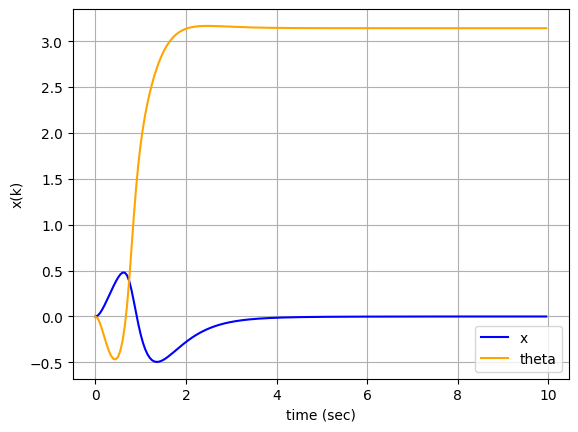

In [27]:
plot_x(xtraj)

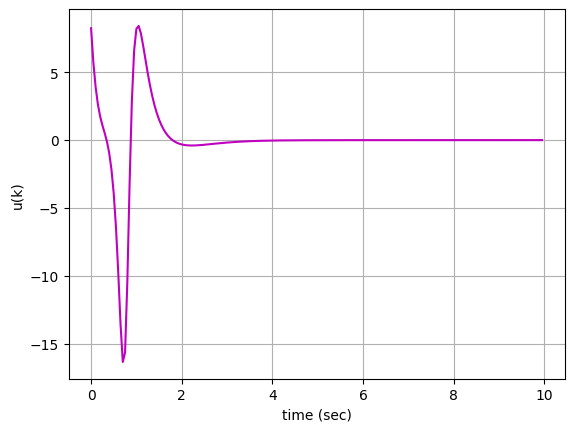

In [28]:
plot_u(utraj)

เราต้องการจำลองสถานะจริงเมื่อป้อนตัวควบคุม utraj ให้กับพลวัตของคาร์ทโพล สามารถดัดแปลงจาก initial_rollout() ด้านบน เป็น rollout() ดังนี้

In [21]:
def rollout():
    global ad_flag
    ad_flag = False
    noise_intensity = 0.01
    xtraj_ol = np.kron(np.ones((1,Nt)),x0) # use xtraj_ol to keep open-loop states
    for k in range(Nt-1):
        xtraj_ol[:,[k+1]] = cartpole_rk4(xtraj_ol[:,[k]]+noise_intensity*np.random.rand(), utraj[k]) # add some random noise to state 
    J = cost(xtraj_ol, utraj)
    print("Cost = "+str(J))
    return xtraj_ol  

โดยมีการเพิ่มค่าการรบกวนน้อยๆ ให้กับสถานะ เพื่อให้เหมือนกับคาร์ทโพลในทางปฎิบัติที่มีค่าผิดพลาดจากการโมเดลและการวัด (ในกรณีนี้เราไม่มีค่าผิดพลาดจากการโมเดล)

In [29]:
xtraj_openloop = rollout()

Cost = 104813.1860445036


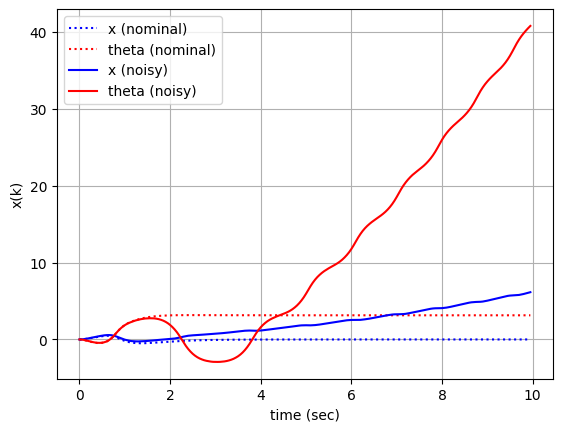

In [32]:
compare_x(xtraj_openloop,name="noisy")

จะเห็นได้ว่าคาร์ทโพลไม่เข้าสู่ค่าสถานะสุดท้ายที่ต้องการ คือลูกตุ้มชี้ขึ้น สามารถจำลองโดย meshcat ได้ตามโค้ดดังนี้

In [33]:
import meshcat
import meshcat.geometry as geo
import meshcat.transformations as tf
import time

In [34]:
vis = meshcat.Visualizer()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7001/static/


In [35]:
# create cartpole
def build_cartpole(vis):
    cart_pole = vis["cart_pole"]
    cart_pole.delete()
    cart = cart_pole["cart"]
    pivot = cart["pivot"]
    pole = pivot["pole"]
    pendulum = pole["pendulum"]
    cart.set_object(geo.Box([0.5, 0.3, 0.2]))
    pole.set_object(geo.Box([0.05, 0.05, 0.5]))
    pendulum.set_object(geo.Sphere(0.06))
    pole.set_transform(tf.translation_matrix([0, 0, -0.25]))
    pendulum.set_transform(tf.translation_matrix([0.0,0.0,-0.25]))
    # pivot.set_transform(tf.rotation_matrix(-np.pi/2, [0, 1, 0]))
    return cart,pivot

# update cartpole pose
def update_cartpole(x,th):
    cart_th.set_transform(tf.rotation_matrix(th,[0,1,0]))
    cart_x.set_transform(tf.translation_matrix([x, 0, 0]))

def simulate_cartpole(x_traj):
    for k in range(x_traj.shape[1]):
        x = x_traj[0,k] # cart position
        th = x_traj[1,k] # pole angle
        update_cartpole(x,th)
        time.sleep(h)    


In [36]:
cart_x, cart_th = build_cartpole(vis)

In [37]:
simulate_cartpole(xtraj_openloop)

***

<a id="p2"></a>

## P2 (3 คะแนน)

สร้างเสถียรภาพแนววิถีอย่างง่ายโดยใช้ตัวควบคุม LQR แบบแนวนอนอนันต์ โดยเลือกจุดโครงแบบ (configuration) หรือโพส (pose) หนึ่งจากคาร์ทโพล เช่นตำแหน่งสุดท้าย ประมาณค่าเมทริกซ์ $A, B$ แล้วคำนวณเมทริกซ์ป้อนกลับสถานะ $K$ โดยใช้ dlqr() จาก Python Control library (ดูตัวอย่างจากบทที่ 3 หรือบทที่ 4) 

ใช้ตัวควบคุมป้อนกลับสถานะ $K$ ที่คำนวณได้เป็นตัวควบคุมค่าคงที่ เพื่อสร้างเสถียรภาพให้กับแนววิถี โดยให้อัตราของตัวควบคุมสูงกว่าอัตราของค่าตั้งจากแนววิถี 10 เท่า (เช่นตั้งค่าขั้นเวลาลูปควบคุม 0.005 วินาที ขณะที่ขั้นเวลาของแนววิถี 0.05 วินาที)

เก็บค่าสถานะ $x$ และตัวควบคุม $u$ จากระบบวงปิด พล็อตค่า $x,u$ ที่เปลี่ยนแปลงตามขั้นเวลาเปรียบเทียบกับแนววิถีเป้าหมาย และจำลองการเคลื่อนที่โดย meshcat 

ตัวควบคุมคงที่นี้สามารถสร้างเสถียรภาพได้หรือไม่ ให้เหตุผลประกอบ 

### Solution

In [38]:
import control as ctl

การคำนวณตัวควบคุม LQR แบบแนวนอนอนันต์ เริ่มต้นจากการประมาณค่าเมทริกซ์ A, B ในที่นี้เราเลือกค่าสถานะเป็นตำแหน่งสุดท้าย

In [41]:
xgoal

array([[0.        ],
       [3.14159265],
       [0.        ],
       [0.        ]])

In [42]:
x_N = xgoal #xtraj[:,[-1]]
u_N = 0.0 #utraj[-1]
if use_torch:
    xN_grad = torch.tensor(x_N,requires_grad=True)
    uN_grad = torch.tensor(u_N,requires_grad=True)
    ad_flag = True
    A_N = dfdx(xN_grad,uN_grad).detach().numpy()
    B_N = dfdu(xN_grad,uN_grad).detach().numpy()
    ad_flag = False
else:
    A_N = dfdx(xtraj[:,[k]], utraj[k])
    B_N = dfdu(xtraj[:,[k]], utraj[k])
    

In [43]:
A_N

array([[ 1.00000000e+00,  2.05509021e-03,  5.00000000e-02,
         3.12712741e-05],
       [ 0.00000000e+00,  9.75477878e-01,  0.00000000e+00,
         4.96300173e-02],
       [ 0.00000000e+00,  9.88891287e-02,  1.00000000e+00,
         2.09698402e-03],
       [ 0.00000000e+00, -1.17570778e+00,  0.00000000e+00,
         9.75323968e-01]])

In [45]:
B_N

array([[ 0.00104113],
       [-0.00207708],
       [ 0.04993553],
       [-0.09925001]])

คำนวณตัวควบคุม Kf จากแพ็กเกจ control

In [46]:
Kf,_,_ = ctl.dlqr(A_N,B_N,Q,R)
Kf

array([[ 2.48928301, -5.2804651 ,  3.86371052, -2.10070542]])

จำลองระบบป้อนลับสถานะ โดยให้ลูปตัวควบคุมมีอัตราเป็น 10 เท่าของลูปแนววิถี ดังนั้นเราต้องสร้างฟังก์ชัน RK4 ใหม่โดยปรับค่าขั้นเวลาให้ลดลง 10 เท่า เพื่อหาปริพันธ์สำหรับระบบดีสครีตได้อย่างถูกต้อง

In [47]:
def cartpole_rk4_x10(x,u):
    global h_s
    h_s = h/10.0 # smaller h for 10 times faster sampling rate
    if use_torch == False:
        #RK4 integration with zero-order hold on u
        x_1 = x
        f1 = cartpole(x, u)
        
        x_a = x.reshape(4,1)
        x_2 = x_a + 0.5*h_s*f1
        f2 = cartpole(x_2.flatten(), u)
        
        x_3 = x_a + 0.5*h_s*f2
        f3 = cartpole(x_3.flatten(), u)

        x_4 = x_a + 0.5*h_s*f3
        f4 = cartpole(x_4.flatten(), u)

        ft = x_a + (h_s/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    else:
        f1 = cartpole(x, u)
    
        x_2 = x + 0.5*h_s*f1
        f2 = cartpole(x_2, u)
        
        x_3 = x + 0.5*h_s*f2
        f3 = cartpole(x_3, u)

        x_4 = x + 0.5*h_s*f3
        f4 = cartpole(x_4, u)

        ft = x + (h_s/6.0)*(f1 + 2*f2 + 2*f3 + f4)        
    return ft



In [48]:
def cartpole_w_LQR():
    global ad_flag, x_new,u_sfb, u_sfb_vec
    ad_flag = False
    noise_intensity = 0.01
    xtraj_lqr = xtraj.copy() # use xtraj_LQR to keep  states with LQR feedback
    x_new = x0
    u_sfb = utraj[0]
    u_sfb_vec = utraj.copy()
    for k in range(Nt-1): # trajectory time step
        for i in range(10): # control loop runs 10 times faster. 
            # print("i = "+str(i))
            x_new_noisy = x_new + noise_intensity*np.random.rand() # add noise to state
            u_sfb = utraj[k] - (Kf@(x_new_noisy - xtraj[:,[k]])).item()
            x_new = cartpole_rk4_x10(x_new_noisy,u_sfb)
        u_sfb_vec[k] = u_sfb
        xtraj_lqr[:,[k+1]] = x_new 
    J = cost(xtraj_lqr, utraj)
    print("Cost = "+str(J))
    return xtraj_lqr  

ทดสอบฟังก์ชัน cartpole_w_LQR()

In [49]:
xtraj_LQR = cartpole_w_LQR()

Cost = 5371.839594604577


In [50]:
xtraj_LQR[:,-1]

array([-5.13919943,  0.1498517 , -0.97776966, -0.95422596])

จากการทดสอบจะพบว่าเมื่อใช้ torch ระบบป้อนกลับไม่เสถียรและค่าเข้าสู่ nan ไม่สามารถพล็อตสถานะและจำลองบน meshcat ได้ 
แต่เมื่อใช้ drake ขนาดของสถานะยังพล็อตและจำลองได้

เหตุผลคือในการประมาณค่าเชิงเส้น ค่าเมทริกซ์ $A,B$ เป็นฟังก์ชันของเวลา เราไม่สามารถใช้ตัวควบคุม LQR 
แบบแนวนอนอนันต์ในการสร้างเสถียรภาพให้แนววิถีได้

**หมายเหตุ :** หากค่าที่ได้เป็น nan ไม่ต้องพล็อตสถานะ ตัวควบคุม หรือจำลองระบบโดย meshcat

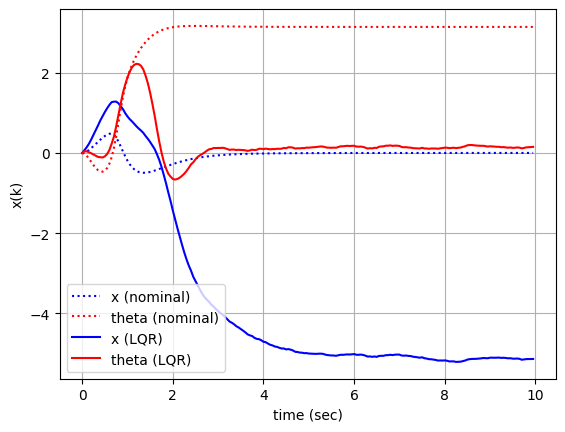

In [52]:
compare_x(xtraj_LQR,name="LQR")

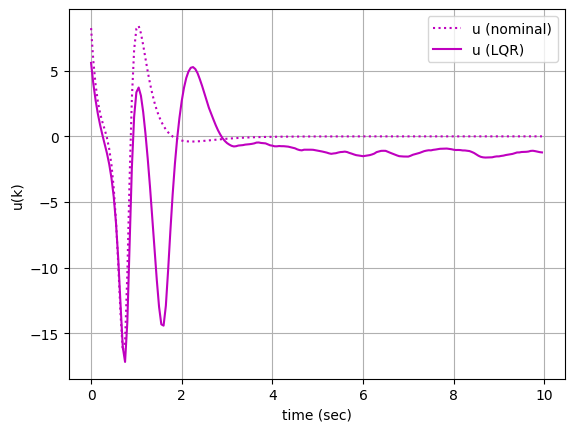

In [56]:
compare_u(u_sfb_vec,name="LQR")

จำลองบน meshcat (ใช้หน้าต่างเดิมเพื่อไม่ต้องโค้ดใหม่)

In [57]:
simulate_cartpole(xtraj_LQR)

### การทดสอบเพิ่มเติมสำหรับ LQR แนวนอนอนันต์

การทดสอบในส่วนท้ายของข้อนี้อยู่นอกเหนือจากคำสั่งในการบ้าน โดยอยากทราบว่าหากเราต้องการใช้ตัวควบคุม LQR กับแนวนอนอนันต์ที่อัตราขยายคำนวณจากการประมาณค่าเชิงเส้นพลวัตคาร์ทโพลที่ตำแหน่งสุดท้าย (ก้านลูกตุ้มชี้ขึ้น) ตัวควบคุมนี้น่าจะใช้การได้เมื่อคาร์ทโพลใกล้เคียงกับตำแหน่งที่ประมาณค่าเท่านั้น คือมุมของก้านต่อเบี่ยงเบนไม่มากจากตำแหน่งตั้งฉาก ดังนั้นในช่วงแกว่งขึ้นเราทดลองป้อนแนววิถีลูปเปิดโดยไม่มีการป้อนกลับ จนเมื่อตรวจสอบว่ามุมเบี่ยงเบนมีค่าน้อยกว่าที่กำหนดแล้วจึงเริ่มการป้อนกลับโดยใช้อัตราขยายคงที่ $K$ ที่ได้จาก LQR แนวนอนอนันต์ 
โค้ดด้านล่างนี้เป็นการทดสอบวิธีการดังกล่าว

In [58]:
def cartpole_w_LQR_ATE():  # ATE stands for "at the end"
    global ad_flag, x_new,u_sfb, u_sfb_vec, xtraj_ol
    fb_active = False  # a flag to activate LQR feedback
    ad_flag = False
    noise_intensity = 0.01
    xtraj_lqr = xtraj.copy() # use xtraj_LQR to keep  states with LQR feedback
    x_new = x0
    u_sfb = utraj[0]
    u_sfb_vec = utraj.copy()
    xtraj_ol = np.kron(np.ones((1,Nt)),x0) # use xtraj_ol to keep open-loop states
    for k in range(Nt-1): # trajectory time step
        # x_traj = xtraj[:,[k]]
        
        # activate fb_active when the rod angle is small enough
        if np.abs(np.abs(x_new[1,0]) - np.pi)<0.01:
            fb_active = True
            print("Feedback activated")
        if not fb_active:
            xtraj_ol[:,[k+1]] = cartpole_rk4(xtraj_ol[:,[k]]+noise_intensity*np.random.rand(), utraj[k]) # add some random noise to state 
            x_new = xtraj_ol[:,[k+1]]  # open-loop trajectory and control
            u_sfb = utraj[k]  
        else:  # apply feedback control
            for i in range(10): # control loop runs 10 times faster. 
                # print("i = "+str(i))
                x_new_noisy = x_new + noise_intensity*np.random.rand()
                # print('k = '+str(k))
                # print('x_new = ' +str(x_new))
                # print('x_new_noisy = '+str(x_new_noisy))
                u_sfb = utraj[k]   - (Kf@(x_new_noisy - xtraj_ol[:,[k+1]])).item()
                x_new = cartpole_rk4_x10(x_new_noisy,u_sfb)
                # x_new = cartpole_rk4(x_new_noisy, u_sfb)
        u_sfb_vec[k] = u_sfb
        xtraj_lqr[:,[k+1]] = x_new 
    J = cost(xtraj_lqr, utraj)
    print("Cost = "+str(J))
    return xtraj_lqr  

In [59]:
xtraj_LQR_ATE = cartpole_w_LQR_ATE()

Feedback activated
Cost = 29115.999378766188


แต่จากผลการจำลองพบว่าไม่สามารถทำงานได้อย่างที่คาดหวัง เพราะพลวัตเป็นแบบไม่เป็นเชิงเส้น การปิดวงป้อนกลับในขณะที่ก้านต่อมีแรงเหวี่ยงไม่สามารถจะประคองให้ลูกตุ้มอยู่ในแนวดิ่งได้ทันเวลา

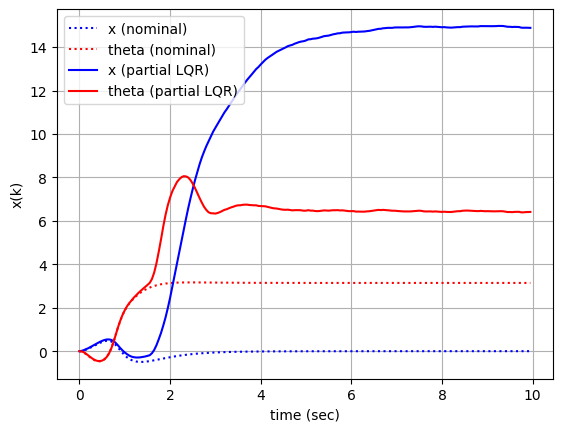

In [60]:
compare_x(xtraj_LQR_ATE,name="partial LQR")

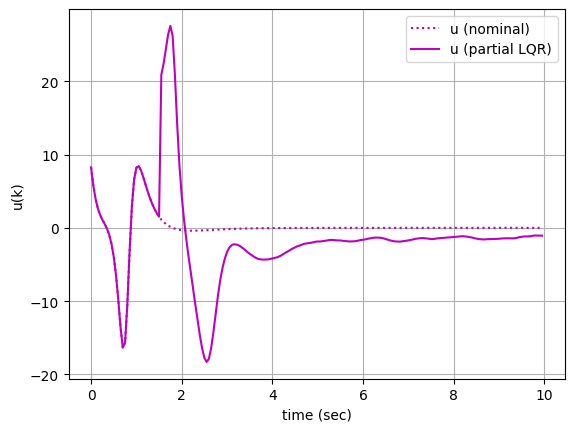

In [61]:
compare_u(u_sfb_vec,name="partial LQR")

In [62]:
simulate_cartpole(xtraj_LQR_ATE)

***

<a id="p3"></a>

## P3 (4 คะแนน)

ใช้โครงสร้างตัวควบคุมเดียวกับข้อ P2 แต่เปลี่ยนตัวควบคุม LQR แบบเวลาแปรผัน (time varying) ที่ค่าของตัวควบคุมป้อนกลับสถานะ $K_i$ เปลี่ยนไปทุกขั้นเวลาใหม่ของแนววิถี ซึ่งตัวควบคุมนี้ได้จากการรันอัลอริทึม DDP/iLQR (อาจต้องเพิ่มเวกเตอร์เพื่อเก็บค่ามาใช้งาน)

เก็บค่าสถานะ $x$ และตัวควบคุม $u$ จากระบบวงปิด พล็อตค่า $x,u$ ที่เปลี่ยนแปลงตามขั้นเวลาเปรียบเทียบกับแนววิถีเป้าหมาย และจำลองการเคลื่อนที่โดย meshcat 

ตัวควบคุมคงที่นี้สามารถสร้างเสถียรภาพได้หรือไม่ ให้เหตุผลประกอบ 

### Solution

สังเกตว่าในการรันอัลกอริทึม iLQR จะได้อัตราขยายป้อนกลับของ TVLQR โดยอัตโนมัติ ซึ่งถูกเก็บอยู่ในเทนเซอร์ K เราสามารถใช้อัตราขยายป้อนกลับนี้ได้ทันที สร้างฟังก์ชัน cartpaole_w_TVLQR() ดังนี้

In [63]:
def cartpole_w_TVLQR():
    # use time-varying state feedback K from iLQR algorithm
    global ad_flag, x_new,u_sfb_vec,k,u_sfb
    ad_flag = False
    noise_intensity = 0.01
    xtraj_tvlqr = xtraj.copy() # use xtraj_LQR to keep  states with LQR feedback
    x_new = x0
    u_sfb = utraj[0]
    u_sfb_vec = utraj.copy()
    for k in range(Nt-1): # trajectory time step
        x_traj = xtraj[:,[k]]
        for i in range(10): # make control loop runs 10 times faster. Does not work!
            # print("i = "+str(i))
            x_new_noisy = x_new + noise_intensity*np.random.rand()
            u_sfb = utraj[k] - (K[:,:,k]@(x_new_noisy - x_traj)).item()
            x_new = cartpole_rk4_x10(x_new_noisy,u_sfb)


        u_sfb_vec[k] = u_sfb
        xtraj_tvlqr[:,[k+1]] = x_new 
    J = cost(xtraj_tvlqr, utraj)
    print("Cost = "+str(J))
    return xtraj_tvlqr, u_sfb_vec  

เรียกฟังก์ชันเพื่อจำลองระบบและคืนค่าสถานะและตัวควบคุม

In [64]:
xtraj_TVLQR, utraj_TVLQR = cartpole_w_TVLQR()

Cost = 722.6470311716347


พล็อตเพื่อดูค่าสถานะและตัวควบคุม

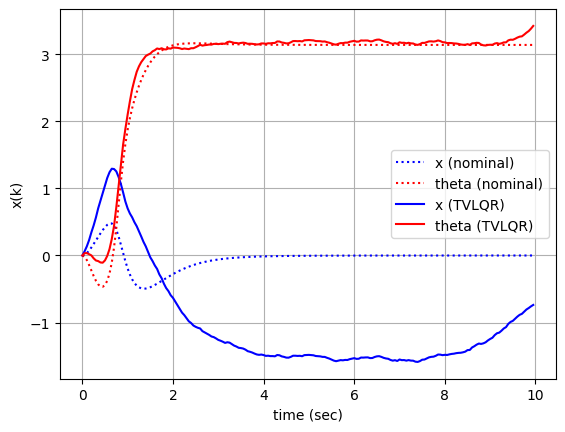

In [65]:
compare_x(xtraj_TVLQR,name="TVLQR")

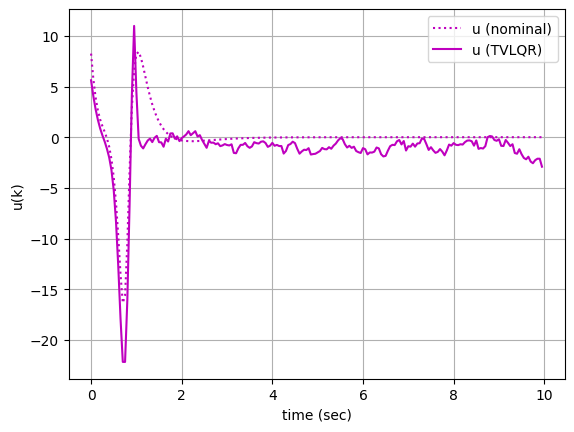

In [66]:
compare_u(utraj_TVLQR,name="TVLQR")

จำลองบน meshcat (ใช้หน้าต่างเดิมเพื่อไม่ต้องโค้ดใหม่)

In [68]:
simulate_cartpole(xtraj_TVLQR)

**หมายเหตุ :** 

1. หากต้องการจำลองโดยใช้เวลามากขึ้นเพื่อดูเสถียรภาพของแนววิถี จะต้องรันอัลกอริทึม iLQR ใหม่โดยเพิ่มค่าเวลาสิ้นสุด
2. จากการทดสอบพบว่าเมื่อเพิ่มความแรงของการรบกวนถึงระดับหนึ่ง ตัวควบคุมไม่สามารถรักษาเสถียรภาพได้


<div align="right">Rev 1A : 20 กุมภาพันธ์ 2569</div>

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>